Training Sigmoid ...
Training ReLU ...
Training Tanh ...
Training LeakyReLU ...


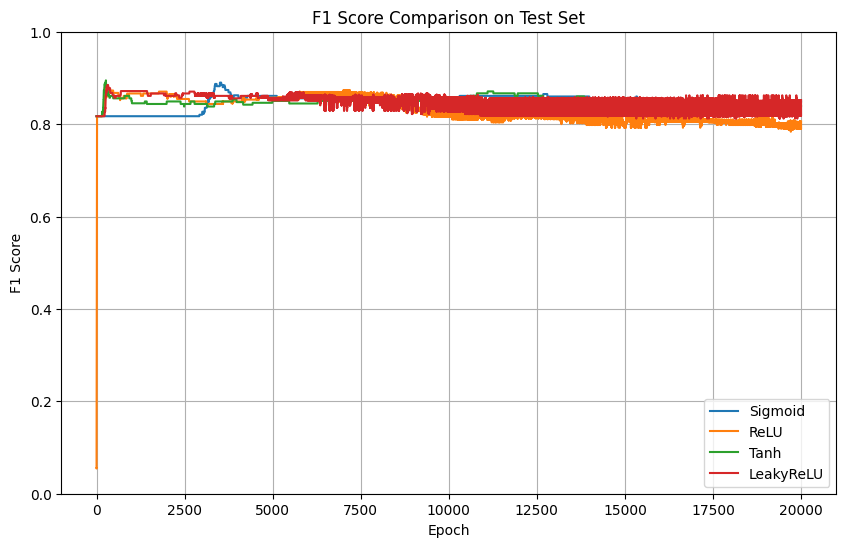

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---------- 1. 加载数据 ----------
xy = np.loadtxt('../diabetes.csv.gz', delimiter=',', dtype=np.float32)
X = torch.from_numpy(xy[:, :-1])
Y = torch.from_numpy(xy[:, [-1]])

# 划分训练/测试集（用于画F1曲线）
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# ---------- 2. 定义可配置激活函数的模型 ----------
class Model(torch.nn.Module):
    def __init__(self, activation):
        super(Model, self).__init__()
        self.linear1 = torch.nn.Linear(8, 6)
        self.linear2 = torch.nn.Linear(6, 4)
        self.linear3 = torch.nn.Linear(4, 1)
        self.activate = activation
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.activate(self.linear1(x))
        x = self.activate(self.linear2(x))
        x = self.sigmoid(self.linear3(x))
        return x

# ---------- 3. 训练参数 ----------
epochs = 20000
lr = 0.1

# 待比较的激活函数
activations = {
    'Sigmoid': torch.nn.Sigmoid(),
    'ReLU': torch.nn.ReLU(),
    'Tanh': torch.nn.Tanh(),
    'LeakyReLU': torch.nn.LeakyReLU(0.01)
}

# 存储各激活函数的F1曲线
f1_records = {}

for name, act_fn in activations.items():
    print(f'Training {name} ...')  # 可注释掉以静默运行
    model = Model(act_fn)
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    f1_list = []
    for epoch in range(epochs):
        # 训练
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, Y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 测试集评估F1
        model.eval()
        with torch.no_grad():
            y_test_pred = model(X_test)
            y_class = (y_test_pred > 0.5).float()
            TP = ((y_class == 1) & (Y_test == 1)).sum().float()
            FP = ((y_class == 1) & (Y_test == 0)).sum().float()
            FN = ((y_class == 0) & (Y_test == 1)).sum().float()
            precision = TP / (TP + FP + 1e-8)
            recall = TP / (TP + FN + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            f1_list.append(f1.item())

    f1_records[name] = f1_list

# ---------- 4. 绘制F1对比图（最终图片） ----------
plt.figure(figsize=(10, 6))
for name, f1_list in f1_records.items():
    plt.plot(f1_list, label=name)
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison on Test Set')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()